# 🖥️🤖 Regression Model Performance Comparison  

* 📊 VISUALIZATION 

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "../data/model_comparison_results.csv"

results_df = pd.read_csv(DATA_PATH)
print(results_df)

               model          mae           mse         rmse        r2
0      Random Forest  1060.283471  7.035489e+06  2652.449618  0.892698
1      Decision Tree  1380.306590  1.232556e+07  3510.777278  0.812016
2  Gradient Boosting  1541.868062  9.637792e+06  3104.479365  0.853009
3  Linear Regression  2077.962973  1.934385e+07  4398.164312  0.704976


### 🌡️ Model Performance Heatmap

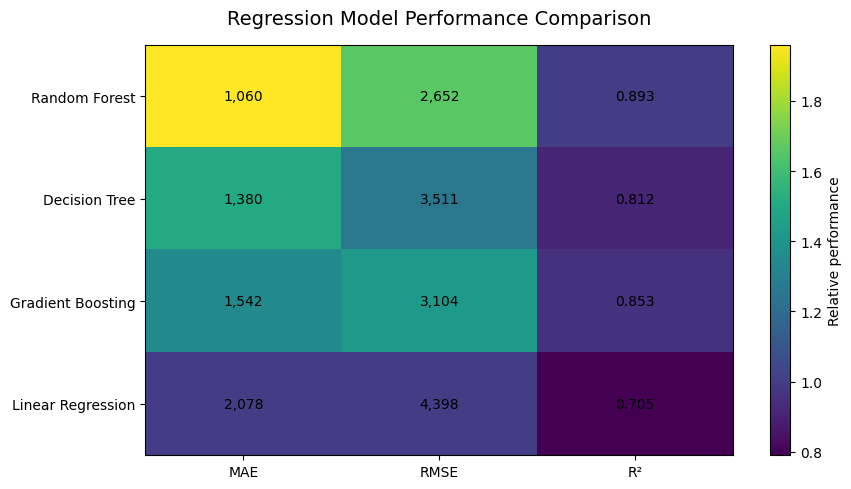

In [23]:
# Prepare data
heatmap_data = results_df.set_index("model")[
    ["mae", "rmse", "r2"]
].copy()

heatmap_data.columns = [
    "MAE",
    "RMSE",
    "R²"
]


# Normalize values only for visualization
visual_data = heatmap_data.copy()

visual_data["MAE"] = (
    visual_data["MAE"].max() / visual_data["MAE"]
)

visual_data["RMSE"] = (
    visual_data["RMSE"].max() / visual_data["RMSE"]
)

visual_data["R²"] = (
    visual_data["R²"] / visual_data["R²"].max()
)


# Create heatmap
fig, ax = plt.subplots(figsize=(9, 5))

im = ax.imshow(
    visual_data,
    aspect="auto"
)

ax.set_xticks(range(len(visual_data.columns)))
ax.set_xticklabels(visual_data.columns)

ax.set_yticks(range(len(visual_data.index)))
ax.set_yticklabels(visual_data.index)

ax.set_title(
    "Regression Model Performance Comparison",
    fontsize=14,
    pad=15
)


# Show actual values inside cells
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):

        value = heatmap_data.iloc[i, j]

        if heatmap_data.columns[j] == "R²":
            text = f"{value:.3f}"
        else:
            text = f"{value:,.0f}"

        ax.text(
            j,
            i,
            text,
            ha="center",
            va="center"
        )


plt.colorbar(
    im,
    ax=ax,
    label="Relative performance"
)

plt.tight_layout()
plt.show()

🏆 Conclusion

The Random Forest Regressor achieved the best overall performance among the four tested models. It obtained the lowest MAE (1,060 USD) and RMSE (2,652 USD), while also achieving the highest R² score (0.893).

This means that the Random Forest model explains approximately 89.3% of the variation in car prices and provides the most accurate predictions on the test dataset.

Therefore, Random Forest was selected as the final model for this project.